## Load data

Dark reference shape: (1, 512, 204)
White reference shape: (1, 512, 204)
Test image shape: (512, 512, 204)


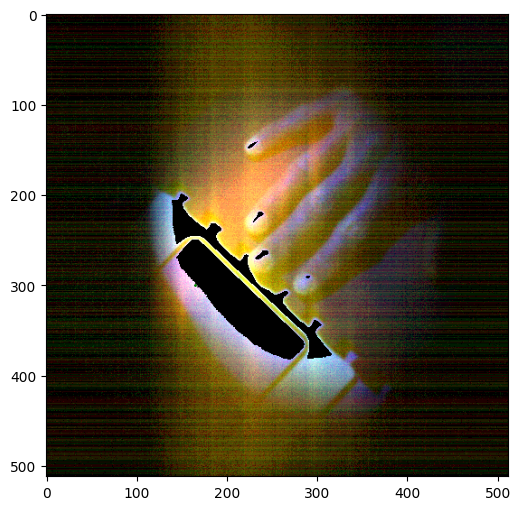

In [3]:
import spectral as spy
import numpy as np
import matplotlib.pyplot as plt


path_to_data = "/Users/StefZ/Library/Mobile Documents/com~apple~CloudDocs/Documents/Documents – Stef’s MacBook Pro/Morphos/Experiments/20260602 - HSI Bruise/Data/Raw/"
folder_name = "2026-06-10_005"
# Load the data
dark_data = spy.open_image(path_to_data + folder_name + "/capture/DARKREF_"+folder_name+".hdr").load()
white_data = spy.open_image(path_to_data + folder_name + "/capture/WHITEREF_"+folder_name+".hdr").load()
sample_data = spy.open_image(path_to_data + folder_name + "/capture/"+folder_name+".hdr").load()
print(f"Dark reference shape: {dark_data.shape}")
print(f"White reference shape: {white_data.shape}")
print(f"Test image shape: {sample_data.shape}")


# Extract spectrum from center of image
h, w, bands = sample_data.shape
# # Create wavelength array (Specim IQ: 400-1000 nm, 204 bands)
wavelengths = np.linspace(400, 1000, bands)


plt.figure(figsize=(12, 6))
plt.imshow(plt.imread(path_to_data + folder_name + "/"+folder_name+".png"))
plt.scatter(165, 300, c='green', s=1, marker='o')
# plt.axis("off")
plt.show()

## Calibrate data

In [4]:

sample_data = sample_data.astype(np.float32)
dark_data = dark_data.astype(np.float32)
white_data = sample_data[165, 300, :].astype(np.float32)
# Calculate mean dark and white values across spatial dimensions
# Add small epsilon (1e-8) to avoid division by zero
calibrated = np.divide(sample_data - dark_data, white_data - dark_data + 1e-8)
print(f"np.mean(sample_data): {np.mean(sample_data)}")
print(f"np.mean(dark_data): {np.mean(dark_data)}")
print(f"np.mean(white_data): {np.mean(white_data)}")
print(f"np.mean(calibrated): {np.mean(calibrated)}")

np.mean(sample_data): 262.5090026855469
np.mean(dark_data): 239.58917236328125
np.mean(white_data): 279.14215087890625
np.mean(calibrated): 2207084.75


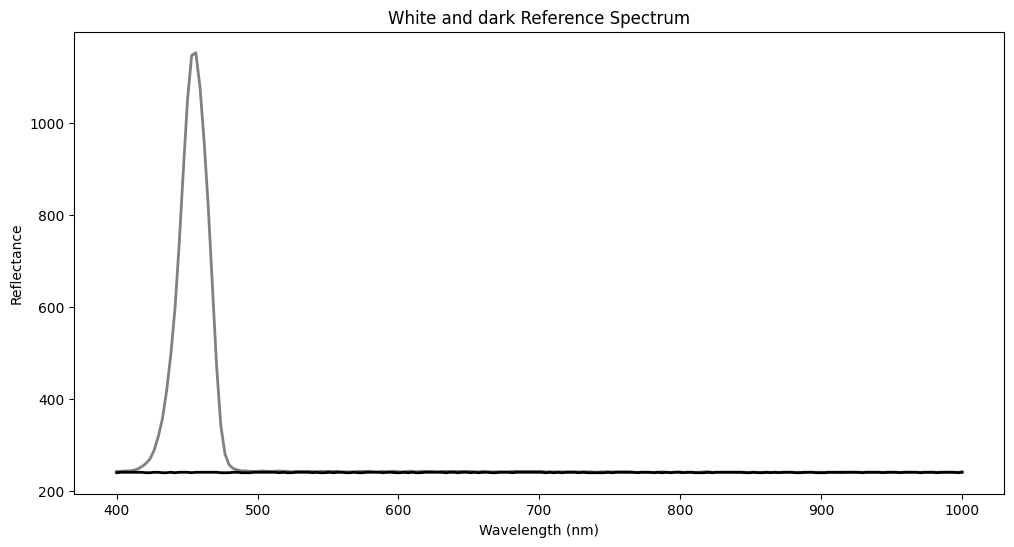

In [5]:
# Plot white reference spectrum 
plt.figure(figsize=(12, 6))
plt.title("White and dark Reference Spectrum")
plt.plot(wavelengths, np.squeeze(white_data), linewidth=2, color='gray')
plt.plot(wavelengths, np.squeeze(dark_data[0,256,:]), linewidth=2, color='black')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.show()
# white_data.shape

## Visualize spectrum for single pixel (e.g., center pixel)

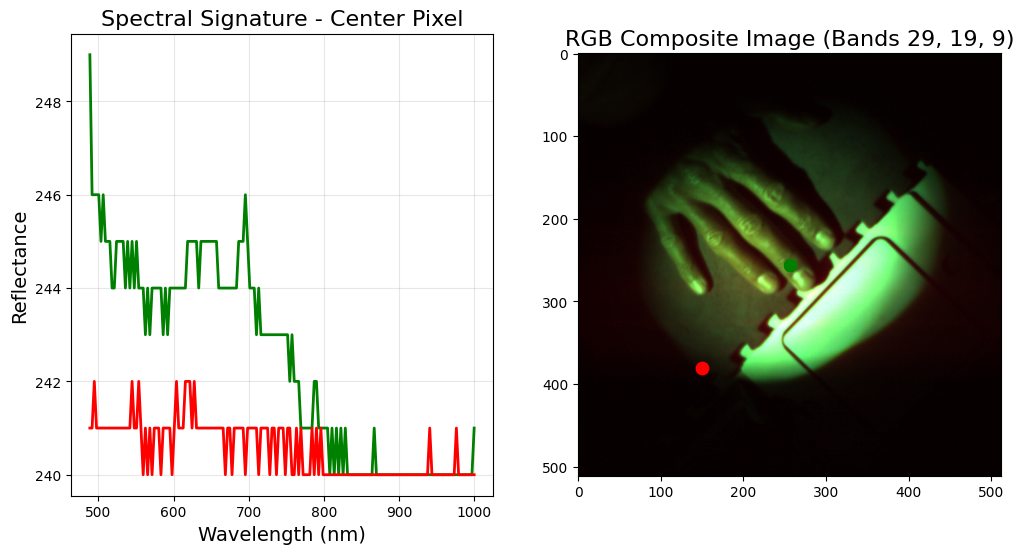

In [6]:
rgb = spy.get_rgb(sample_data, [29, 19, 9])
center_y, center_x = h // 2, w // 2
# Plot spectrum
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(wavelengths[30:], np.squeeze(sample_data[center_y, center_x, 30:]), linewidth=2, color='green')
plt.plot(wavelengths[30:], np.squeeze(sample_data[150, 380, 30:]), linewidth=2, color='red')
plt.xlabel('Wavelength (nm)', fontsize=14)
plt.ylabel('Reflectance', fontsize=14)
plt.title('Spectral Signature - Center Pixel', fontsize=16)
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.imshow(rgb)
plt.title('RGB Composite Image (Bands 29, 19, 9)', fontsize=16)
plt.scatter(center_x, center_y, c='green', s=80, marker='o')
plt.scatter(150,380, c='red', s=80, marker='o')
# plt.axis('off')

# Save spectrum plot
# print("Spectrum plot saved: center_pixel_spectrum.png")
plt.show()

## Image for a specific wavelength

In [7]:
import ipywidgets as widgets
from IPython.display import display
band = 100  # default band index
def show_band(b):
    plt.figure(figsize=(12, 6))
    plt.imshow(calibrated[:, :, b], cmap='gray')
    plt.title(f"Test Image (Band {b}, wavelength {wavelengths[b]:.1f} nm)")
    plt.axis("off")
    plt.show()

band_slider = widgets.IntSlider(
    value=band,
    min=0,
    max=calibrated.shape[2] - 1,
    step=1,
    description="Band",
    continuous_update=True
)

widgets.interactive_output(show_band, {"b": band_slider})
band_slider.unobserve_all()  # avoid duplicate callbacks
out = widgets.interactive_output(show_band, {"b": band_slider})
display(widgets.VBox([band_slider, out]))

# Multiplicative Scatter Correction

In [8]:
# Implement Multiplicative Scatter Correction (MSC)
# MSC removes multiplicative effects by correcting each spectrum to a reference

# Calculate the mean spectrum as reference
mean_spectrum = np.mean(calibrated, axis=(0, 1))

# Initialize MSC corrected data
msc_corrected = np.zeros_like(calibrated)

# Apply MSC to each pixel
for i in range(calibrated.shape[0]):
    for j in range(calibrated.shape[1]):
        # Get pixel spectrum
        pixel_spectrum = calibrated[i, j, :]
        
        # Fit: pixel = a + b * mean_spectrum
        # Using least squares: minimize sum((pixel - a - b*mean)^2)
        A = np.column_stack([np.ones(len(mean_spectrum)), mean_spectrum])
        coeffs = np.linalg.lstsq(A, pixel_spectrum, rcond=None)[0]
        a, b = coeffs
        
        # Correct: msc_spectrum = (pixel - a) / b
        msc_corrected[i, j, :] = (pixel_spectrum - a) / (b + 1e-8)

print(f"MSC correction applied")
print(f"Original calibrated - mean: {np.mean(calibrated):.6f}, std: {np.std(calibrated):.6f}")
print(f"MSC corrected - mean: {np.mean(msc_corrected):.6f}, std: {np.std(msc_corrected):.6f}")
print(f"MSC corrected shape: {msc_corrected.shape}")

MSC correction applied
Original calibrated - mean: 2207084.750000, std: 21218576.000000
MSC corrected - mean: 2195988.500000, std: 1743894609920.000000
MSC corrected shape: (512, 512, 204)


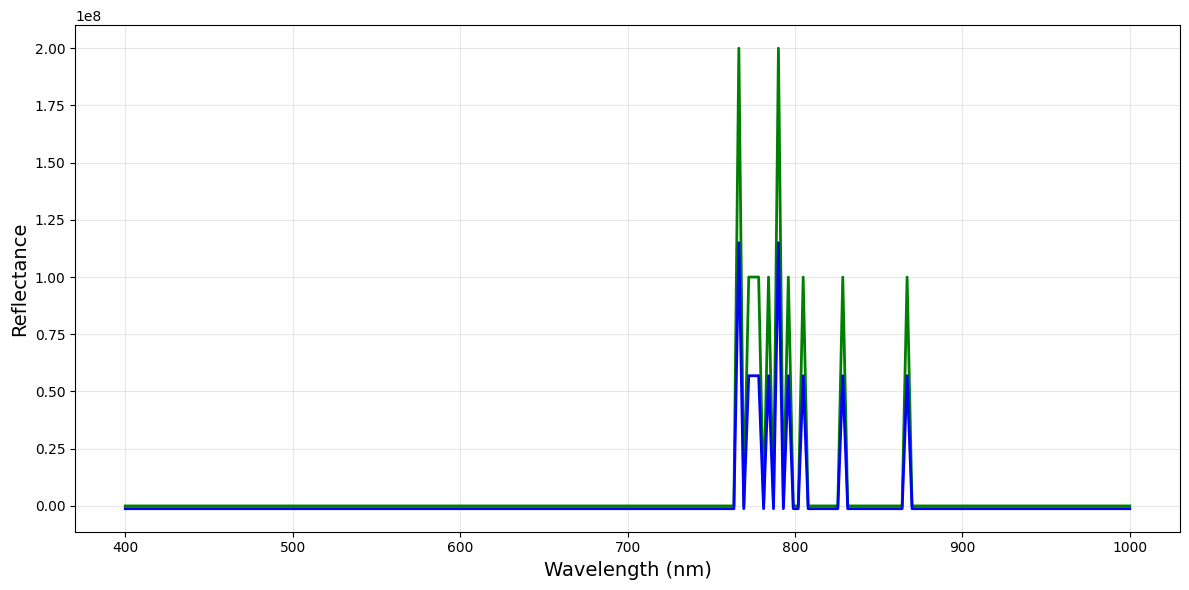

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(wavelengths, np.squeeze(calibrated[h//2, w//2, :]) , linewidth=2, color='green')
plt.xlabel('Wavelength (nm)', fontsize=14)
plt.ylabel('Reflectance', fontsize=14)
plt.plot(wavelengths, np.squeeze(msc_corrected[h//2, w//2, :]), linewidth=2, color='blue')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/km/mvb1lwjd5xs2dt77664dzw4c0000gn/T/ipykernel_3523/3830413396.py:6: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1, 2, 1)


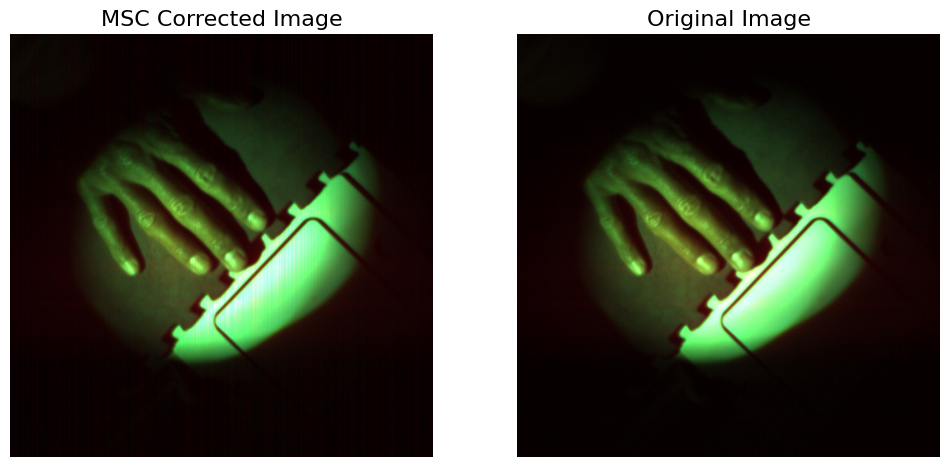

In [11]:
rgb_MSC = spy.get_rgb(calibrated, [29, 19, 9])
band = 55

plt.figure(figsize=(12, 6))
plt.axis("off")
plt.subplot(1, 2, 1)
plt.imshow(rgb_MSC)
plt.title("MSC Corrected Image", fontsize=16)
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(rgb)
plt.title("Original Image", fontsize=16)
plt.axis("off")
plt.show()  


## QUALITY CHECKS


In [12]:


print("\n" + "="*50)
print("CALIBRATION QUALITY CHECKS")
print("="*50)

# Check 1: Dark reference should be near zero
dark_mean_value = np.mean(dark_mean)
print(f"Dark reference mean: {dark_mean_value:.4f} (should be near 0)")

# Check 2: White reference should be significantly higher than dark
white_mean_value = np.mean(white_mean)
print(f"White reference mean: {white_mean_value:.4f}")

# Check 3: Dynamic range
dynamic_range = white_mean_value - dark_mean_value
print(f"Dynamic range: {dynamic_range:.4f}")

# Check 4: Calibrated values should be mostly between 0 and 1
valid_pixels = np.sum((calibrated >= 0) & (calibrated <= 1.2))
total_pixels = calibrated.size
percent_valid = 100 * valid_pixels / total_pixels
print(f"Valid calibrated pixels: {percent_valid:.1f}%")

if percent_valid > 95:
    print("\nCalibration quality: EXCELLENT")
elif percent_valid > 85:
    print("\nCalibration quality: GOOD (minor issues)")
else:
    print("\nCalibration quality: POOR (recapture references)")

print("="*50)



CALIBRATION QUALITY CHECKS


NameError: name 'dark_mean' is not defined

## K-means clustering

ROI calibrated shape: (300, 100, 204)
ROI reshaped shape: (30000, 204)


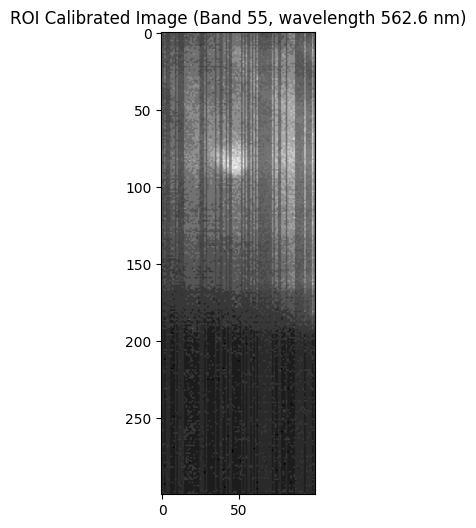

In [14]:
# Region of interest: x = 100:200, y = 200:500
roi_calibrated = calibrated[200:500, 100:200, :]

# Reshape ROI hypercube to (num_pixels, num_bands)
roi_X = roi_calibrated.reshape(-1, roi_calibrated.shape[2])

print(f"ROI calibrated shape: {roi_calibrated.shape}")
print(f"ROI reshaped shape: {roi_X.shape}")

plt.figure(figsize=(12, 6))
plt.imshow(roi_calibrated[:, :, band], cmap='gray')
plt.title(f"ROI Calibrated Image (Band {band}, wavelength {wavelengths[band]:.1f} nm)")
plt.show()


K-means done: 4 clusters
Cluster map shape: (300, 100)


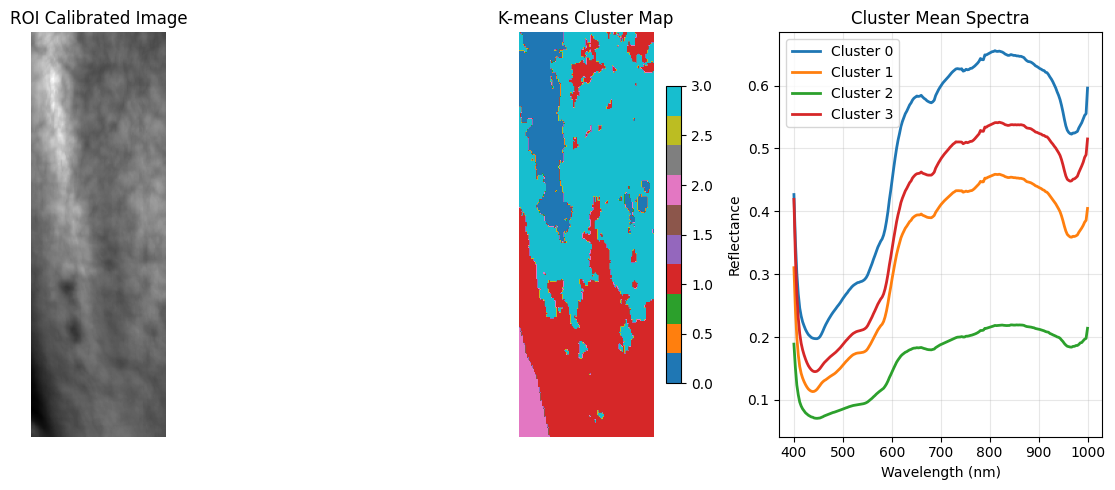

In [ ]:
from sklearn.cluster import KMeans

# Reshape hypercube to (num_pixels, num_bands)
X = calibrated.reshape(-1, calibrated.shape[2])

# K-means clustering
n_clusters = 4  # change if needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(roi_X)

# Reshape labels back to image space
cluster_map = labels.reshape(roi_calibrated.shape[0], roi_calibrated.shape[1])
cluster_centers = kmeans.cluster_centers_

print(f"K-means done: {n_clusters} clusters")
print(f"Cluster map shape: {cluster_map.shape}")

# Visualize cluster map
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(roi_calibrated[:, :, band], cmap='gray')
plt.title("ROI Calibrated Image")
plt.axis("off")
plt.subplot(1, 3, 2)   
plt.imshow(cluster_map, cmap="tab10")
plt.title("K-means Cluster Map")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

# Visualize mean spectrum per cluster
plt.subplot(1, 3, 3)
for c in range(n_clusters):
    plt.plot(wavelengths, cluster_centers[c], linewidth=2, label=f"Cluster {c}")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Cluster Mean Spectra")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Otsumethod
Segmenteer background, en trace
Doe dit per golfrengte, zodat je me meeste contrast kunt berekenen tussen de trace en de background.

Absorbance bekijken (-log van de reflectance)
